In [1]:
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [5]:
df = pd.read_csv("Datasets/dataset.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [10]:
columns_to_drop = [
    "Unnamed: 0",
    "track_id",
    "album_name",
    "key",
    "mode",
    "time_signature",
    "explicit",
    "duration_ms"
]

df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

df.head()

,artists,track_name,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,track_genre
0,Gen Hoshino,Comedy,73,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917,acoustic
1,Ben Woodward,Ghost - Acoustic,55,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489,acoustic
2,Ingrid Michaelson;ZAYN,To Begin Again,57,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332,acoustic
3,Kina Grannis,Can't Help Falling In Love,71,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740,acoustic
4,Chord Overstreet,Hold On,82,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949,acoustic


In [11]:
df.isnull().sum()

artists             1
track_name          1
popularity          0
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
track_genre         0
dtype: int64

In [13]:
df = df.dropna()
df.shape
df.isnull().sum()

artists             0
track_name          0
popularity          0
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
track_genre         0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(7052)

In [15]:
df = df.drop_duplicates()
df.shape
df.duplicated().sum()

np.int64(0)

In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 106947 entries, 0 to 113999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artists           106947 non-null  str    
 1   track_name        106947 non-null  str    
 2   popularity        106947 non-null  int64  
 3   danceability      106947 non-null  float64
 4   energy            106947 non-null  float64
 5   loudness          106947 non-null  float64
 6   speechiness       106947 non-null  float64
 7   acousticness      106947 non-null  float64
 8   instrumentalness  106947 non-null  float64
 9   liveness          106947 non-null  float64
 10  valence           106947 non-null  float64
 11  tempo             106947 non-null  float64
 12  track_genre       106947 non-null  str    
dtypes: float64(9), int64(1), str(3)
memory usage: 11.4 MB


In [17]:
df["popularity"].describe()


count    106947.000000
mean         35.352324
std          21.339007
min           0.000000
25%          20.000000
50%          37.000000
75%          51.000000
max         100.000000
Name: popularity, dtype: float64

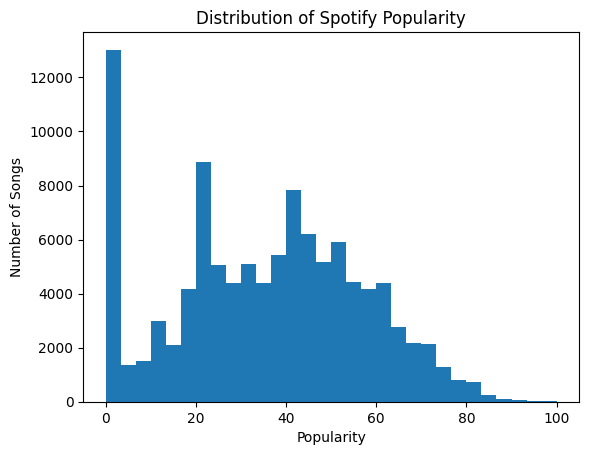

In [18]:
plt.figure()
plt.hist(df["popularity"], bins=30)
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")
plt.title("Distribution of Spotify Popularity")
plt.show()

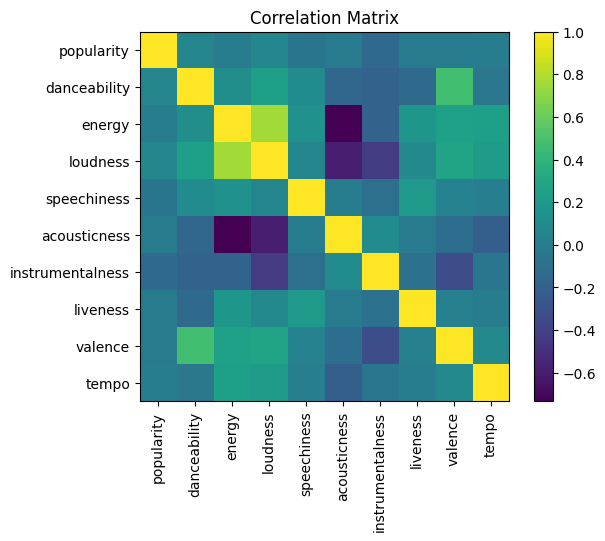

In [19]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure()
plt.imshow(correlation_matrix)
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Correlation Matrix")
plt.colorbar()
plt.show()

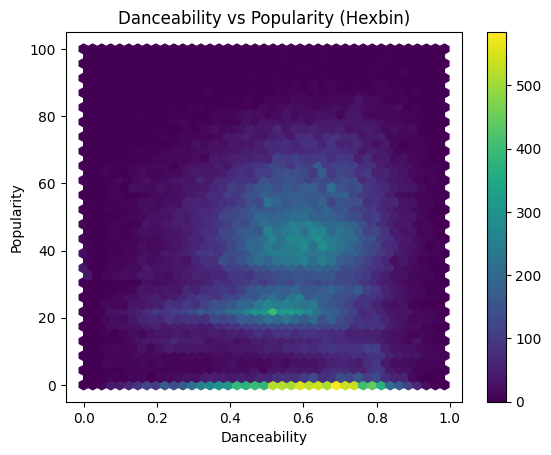

In [27]:
plt.figure()
plt.hexbin(df["danceability"], df["popularity"], gridsize=40)
plt.xlabel("Danceability")
plt.ylabel("Popularity")
plt.title("Danceability vs Popularity (Hexbin)")
plt.colorbar()
plt.show()

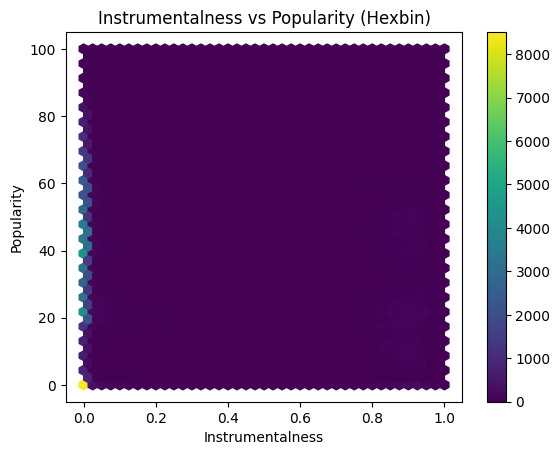

In [28]:
plt.figure()
plt.hexbin(df["instrumentalness"], df["popularity"], gridsize=40)
plt.xlabel("Instrumentalness")
plt.ylabel("Popularity")
plt.title("Instrumentalness vs Popularity (Hexbin)")
plt.colorbar()
plt.show()

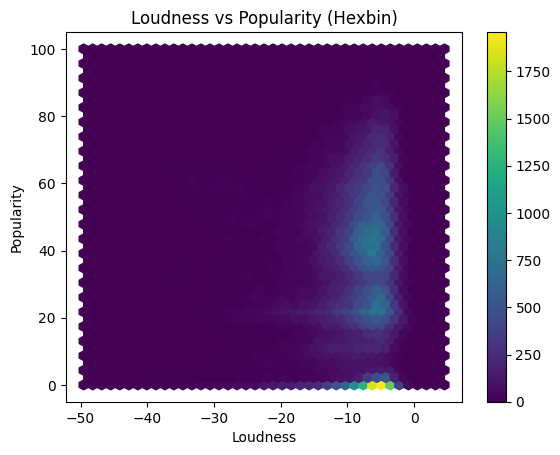

In [29]:
plt.figure()
plt.hexbin(df["loudness"], df["popularity"], gridsize=40)
plt.xlabel("Loudness")
plt.ylabel("Popularity")
plt.title("Loudness vs Popularity (Hexbin)")
plt.colorbar()
plt.show()

In [23]:
df.corr(numeric_only=True)["popularity"].sort_values(ascending=False)

popularity          1.000000
loudness            0.071577
danceability        0.056916
tempo               0.002669
energy             -0.007586
valence            -0.014296
liveness           -0.022844
acousticness       -0.023112
speechiness        -0.061648
instrumentalness   -0.142947
Name: popularity, dtype: float64